# Model Server Demo

This notebook demonstrates how to receive simulations from the server.

In [2]:
import requests
import json
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import cv2

## Server Configuration

In [4]:
SERVER_URL = "http://localhost:8084"

## Check Server Status

In [11]:
# Check if server is running
try:
    response = requests.get(f"{SERVER_URL}/")
    if response.status_code == 200:
        status = response.json()
        print("Server Status:")
        print(json.dumps(status, indent=2))
    else:
        print(f"Server returned status code: {response.status_code}")
except requests.exceptions.ConnectionError:
    print("❌ Server is not running. Please start the server first with: python main.py")
except Exception as e:
    print(f"❌ Error connecting to server: {e}")

Server Status:
{
  "services": {
    "df_aggregation": "ready"
  },
  "status": "running"
}


## Daylight Factor Aggregation Example

In [12]:
# Load predictions and masks from assets
assets_path = Path("../assets")

# Load images for both windows
simulations = {}
for window_name in ["test_window_1"
                    , "test_window_2"
                    ]:
    df_img_path = assets_path / f"{window_name}.png"
    mask_img_path = assets_path / f"mask_{window_name}.png"
    
    # Load DF values (grayscale normalized to 0-1)
    df_img = cv2.imread(str(df_img_path), cv2.IMREAD_GRAYSCALE)
    df_values = df_img.astype(float) / 255.0
    
    # Load mask and resize to match DF dimensions
    mask_img = cv2.imread(str(mask_img_path), cv2.IMREAD_GRAYSCALE)
    # IMPORTANT: Resize mask to match DF dimensions using nearest neighbor
    if mask_img.shape != df_img.shape:
        mask_img = cv2.resize(mask_img, (df_img.shape[1], df_img.shape[0]), 
                             interpolation=cv2.INTER_NEAREST)
    mask = (mask_img > 127).astype(int)
    
    simulations[window_name] = {
        "df_values": df_values.tolist(),
        "mask": mask.tolist()
    }
    
    print(f"✅ Loaded {window_name}:")
    print(f"   - DF shape: {df_values.shape}, range: [{df_values.min():.3f}, {df_values.max():.3f}]")
    print(f"   - Mask shape: {mask.shape}, unique values: {np.unique(mask)}")

# Create payload with correct structure (flat, not nested under parameters)
payload = {
    "room_polygon": [[0, 0], [0, 7], [-3, 7], [-3, 0]],
    "windows": {
        "test_window_1": {
            "x1": 0, "y1": 3.2, "z1": 2.8,
            "x2": 0.4, "y2": 6, "z2": 5.4,
            "window_frame_ratio": 0.41,
            "direction_angle": 0,
        },
        "test_window_2": {
            "x1": -0.7, "y1": 7, "z1": 2.8,
            "x2": -2.0, "y2": 7.3, "z2": 5.4,
            "window_frame_ratio": 0.41,
            "direction_angle": -1.5708,
        }
    },
    "simulations": simulations
}

print(f"\n✅ Payload ready with {len(simulations)} windows")

✅ Loaded test_window_1:
   - DF shape: (384, 384), range: [0.000, 0.102]
   - Mask shape: (384, 384), unique values: [0 1]
✅ Loaded test_window_2:
   - DF shape: (384, 384), range: [0.000, 0.106]
   - Mask shape: (384, 384), unique values: [0 1]

✅ Payload ready with 2 windows


In [28]:
with open("../assets/merger_request_20251214_222552.json", "r") as f:
    payload = json.loads(f.read())

payload.keys()


dict_keys(['room_polygon', 'windows', 'simulations'])

In [29]:
np.unique(payload["simulations"]["test_window_1"]["mask"])

array([0, 1])

✅ Request successful!
DF Matrix shape: (70, 30)
Room Mask shape: (70, 30)
Aggregated DF: 6.7357


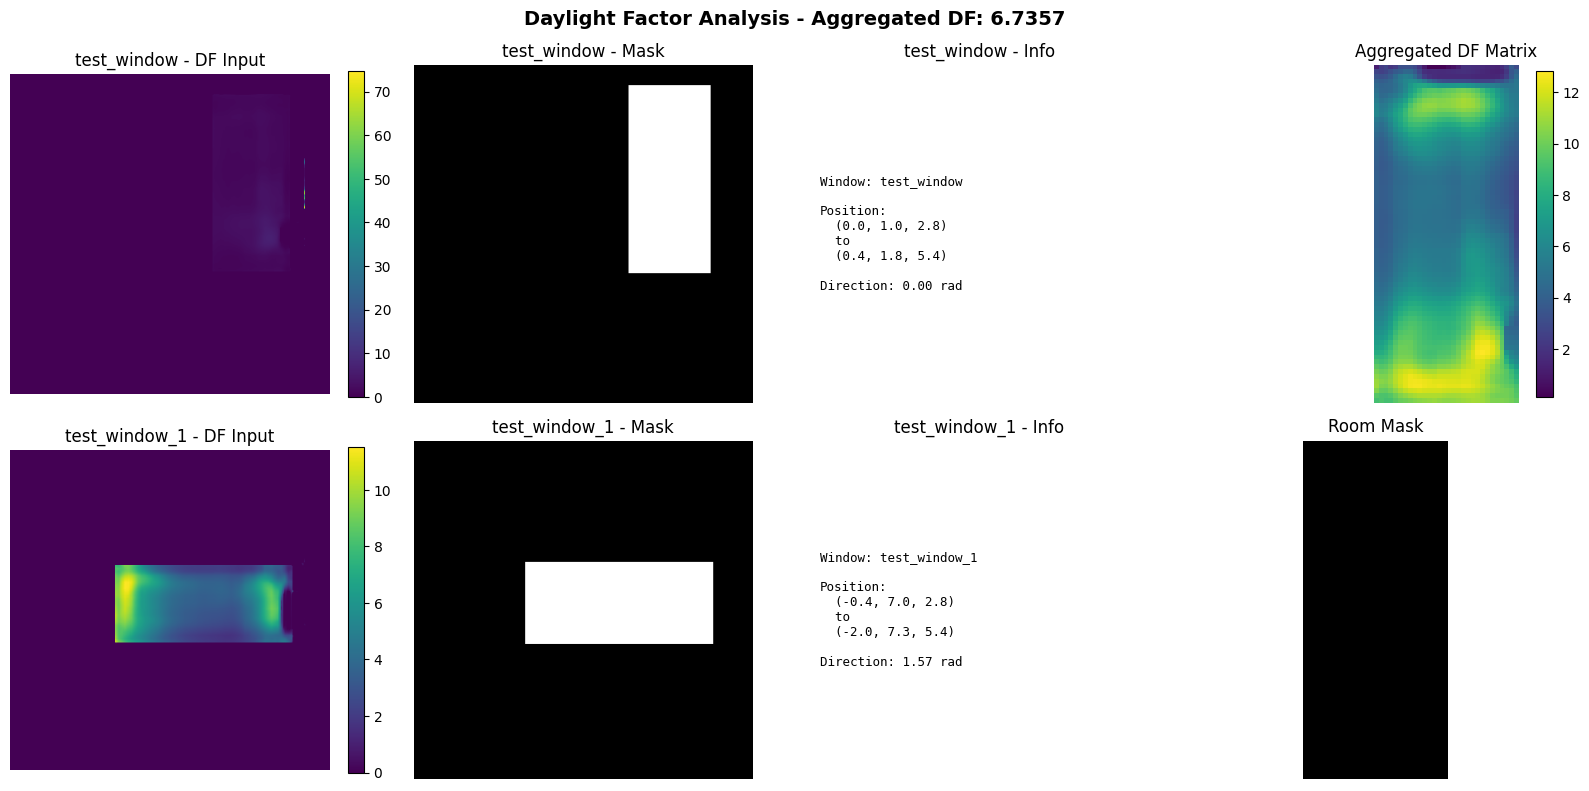

In [36]:
# Send request to server
response = requests.post(f"{SERVER_URL}/merge", json=payload)

if response.status_code == 200:
    result = response.json()
    print("✅ Request successful!")
    
    # Convert to numpy arrays
    df_matrix = np.array(result['result'])
    room_mask = np.array(result['mask'])
    
    # Calculate aggregated DF (mean of masked area)
    masked_df_values = df_matrix[room_mask > 0]
    aggregated_df = masked_df_values.mean() if len(masked_df_values) > 0 else 0.0
    
    print(f"DF Matrix shape: {df_matrix.shape}")
    print(f"Room Mask shape: {room_mask.shape}")
    print(f"Aggregated DF: {aggregated_df:.4f}")
    
    # Create visualization
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    for idx, window_name in enumerate(["test_window"
                                       , "test_window_1"
                                       ]):
        # Load DF prediction
        df_img_path = Path("sdf") #assets_path / f"{window_name}.png"
        mask_img_path = Path("sdf") #assets_path / f"mask_{window_name}.png"
        
        if df_img_path.exists():
            df_img = np.array(Image.open(df_img_path))
        else:
            df_img = np.array(payload["simulations"][window_name]["df_values"])
        im = axes[idx, 0].imshow(df_img, cmap='viridis')
        axes[idx, 0].set_title(f'{window_name} - DF Input')
        axes[idx, 0].axis('off')
        plt.colorbar(im, ax=axes[idx, 0], fraction=0.046)
        
        
        if mask_img_path.exists():
            mask_img = np.array(Image.open(mask_img_path))
        else:
            mask_img = np.array(payload["simulations"][window_name]["mask"])
        axes[idx, 1].imshow(mask_img, cmap='gray')
        axes[idx, 1].set_title(f'{window_name} - Mask')
        axes[idx, 1].axis('off')
        
        # Show window info
        window_data = payload["windows"][window_name]
        info_text = f"Window: {window_name}\n\n"
        info_text += f"Position:\n"
        info_text += f"  ({window_data['x1']:.1f}, {window_data['y1']:.1f}, {window_data['z1']:.1f})\n"
        info_text += f"  to\n"
        info_text += f"  ({window_data['x2']:.1f}, {window_data['y2']:.1f}, {window_data['z2']:.1f})\n\n"
        # info_text += f"Frame ratio: {window_data['window_frame_ratio']:.2f}\n"
        info_text += f"Direction: {window_data['direction_angle']:.2f} rad"
        
        axes[idx, 2].text(0.05, 0.5, info_text, fontsize=9, family='monospace',
                         verticalalignment='center', transform=axes[idx, 2].transAxes)
        axes[idx, 2].set_title(f'{window_name} - Info')
        axes[idx, 2].axis('off')
    
    # Show aggregated results
    im_df = axes[0, 3].imshow(df_matrix, cmap='viridis')
    axes[0, 3].set_title('Aggregated DF Matrix')
    axes[0, 3].axis('off')
    plt.colorbar(im_df, ax=axes[0, 3], fraction=0.046)
    
    axes[1, 3].imshow(room_mask, cmap='gray')
    axes[1, 3].set_title('Room Mask')
    axes[1, 3].axis('off')
    
    plt.suptitle(f'Daylight Factor Analysis - Aggregated DF: {aggregated_df:.4f}', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show() 
    
else:
    print(f"❌ Request failed with status code: {response.status_code}")
    print(response.text)

In [82]:
# Save response.json() to a file in assets_path
assets_path.mkdir(parents=True, exist_ok=True)
output_file = assets_path / "request.json"

try:
    data = payload
    with open(output_file, "w") as f:
        json.dump(data, f, indent=2)
    print(f"✅ Saved response JSON to: {output_file}")
except ValueError:
    print("❌ Response did not contain valid JSON.")
except Exception as e:
    print(f"❌ Error saving response JSON: {e}")

✅ Saved response JSON to: ../assets/request.json
